In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/engage-2-value-from-clicks-to-conversions/sample_submission.csv
/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv
/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv


In [2]:
import warnings
warnings.filterwarnings(action='ignore')

# *Dummy* *Model*

In [3]:
# df = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv")
# X = df.drop("purchaseValue", axis=1) 
# y = df['purchaseValue']
# y.max()
# from sklearn.dummy import DummyRegressor 
# model = DummyRegressor()
# model.fit(X,y) 
# X_test = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv") 
# y_pred=model.predict(X_test) 
# y_pred
# submission = pd.DataFrame({"id": range(0,X_test.shape[0]), "purchaseValue": y_pred}) 
# submission.to_csv('submission.csv',index=False)

# Common Imports

In [4]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from pandas.plotting import scatter_matrix
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from lightgbm import LGBMRegressor

# Data Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv") #train_data
test_df = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv") #test_data


# Exploratory Data Analyses

In [6]:
train_df.head()


,trafficSource.isTrueDirect,purchaseValue,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,...,device.language,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits
0,NaN,0.0,Edge,not available in demo dataset,NaN,NaN,medium,Region_2,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1500100799,Americas,False,1.0
1,True,0.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,1,not available in demo dataset,1495262065,Americas,False,1.0
2,True,0.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_2,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Organic Search,not available in demo dataset,6,not available in demo dataset,1508510328,Europe,False,NaN
3,NaN,0.0,Internet Explorer,not available in demo dataset,NaN,NaN,medium,Region_4,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1483431838,Asia,False,1.0
4,True,88950000.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,...,not available in demo dataset,desktop,Direct,not available in demo dataset,66,not available in demo dataset,1475804633,Americas,False,1.0


In [7]:
print("shape of the data:-", train_df.shape) #shape of the data

print("\nInformation about the training data:") #information of the data
print(train_df.info())

print("\nDescriptive statistics for the training data:") #mean, std, min, max of the data
print(train_df.describe())

print("\nMissing values in the training data:") #checking if there is any null values
print(train_df.isnull().sum())

print("\nthe datatypes:") #checking for datatypes
print(train_df.dtypes)

shape of the data:- (116023, 52)

Information about the training data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116023 entries, 0 to 116022
Data columns (total 52 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   trafficSource.isTrueDirect                    42890 non-null   object 
 1   purchaseValue                                 116023 non-null  float64
 2   browser                                       116023 non-null  object 
 3   device.screenResolution                       116023 non-null  object 
 4   trafficSource.adContent                       2963 non-null    object 
 5   trafficSource.keyword                         44162 non-null   object 
 6   screenSize                                    116023 non-null  object 
 7   geoCluster                                    116023 non-null  object 
 8   trafficSource.adwordsClickInfo.slot           4281 no

<Axes: >

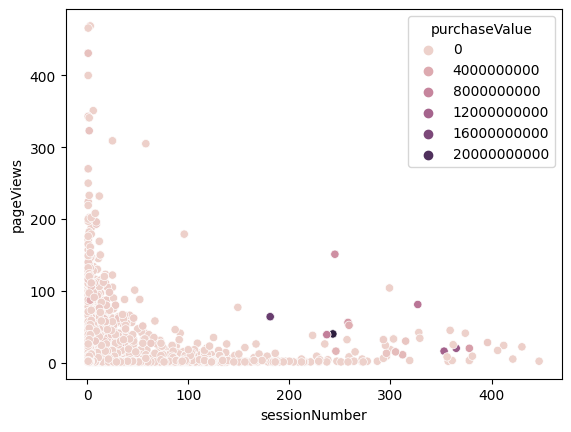

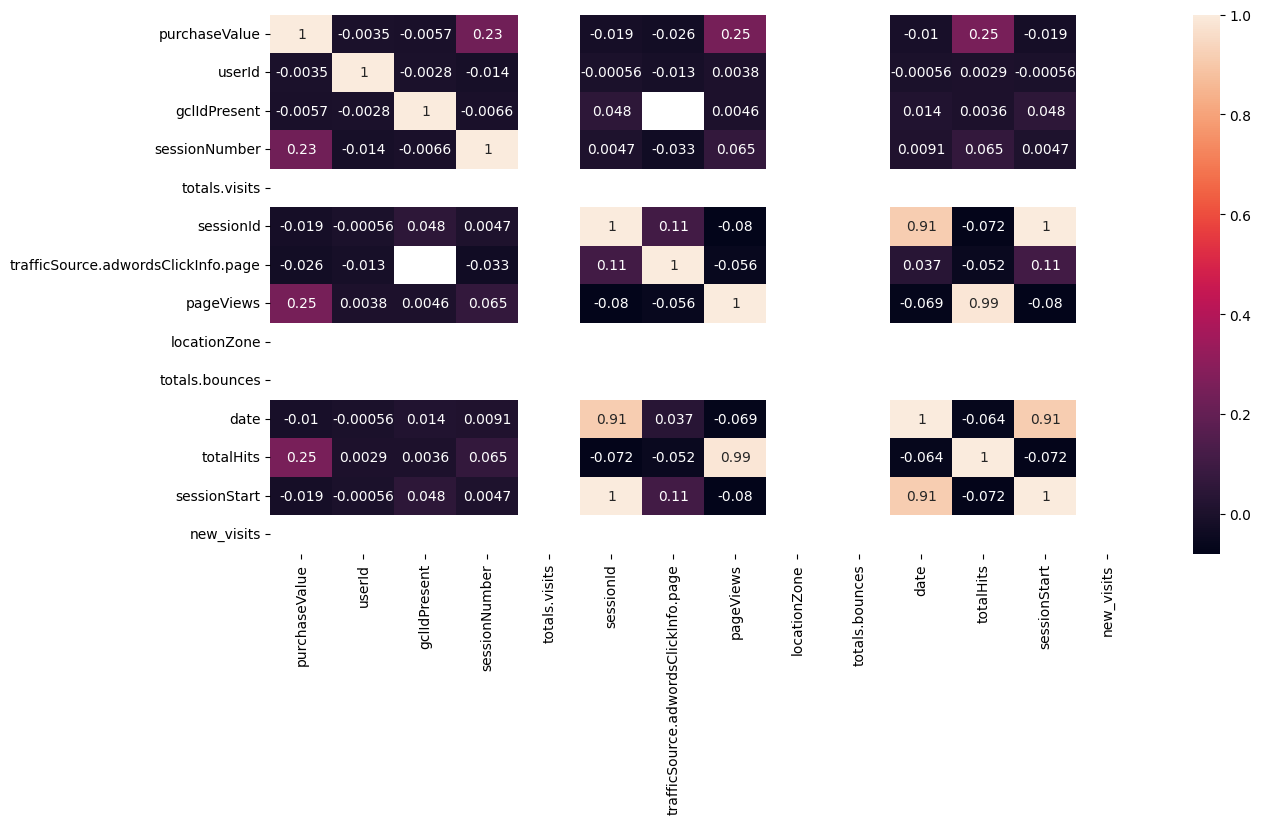

In [8]:
#scatterplot
sample_set = train_df.copy()
sns.scatterplot(x = 'sessionNumber', y = 'pageViews', hue='purchaseValue',data = sample_set)

#heatmap to understand correlation of features and targets
numeric_type = sample_set.select_dtypes(include=np.number).corr()
plt.figure(figsize=(14,7))
sns.heatmap(numeric_type, annot=True)

# Insights -

1. Weak Relationships Across Most Features.
 
The majority of features exhibit weak or near-zero correlation with one another and with the target variable. This suggests the need for feature engineering.

2. Low Correlation with Target Variable (purchaseValue)

The target column shows only slight positive correlation with few features suchs as sessionNumber, pageViews, totalHits
These may serve as initial predictors, but more informative features may need to be derived.

3. Blank or Missing Correlation Values

Some features appear blank or excluded from the correlation matrix due to:
High proportion of missing values
Zero variance (e.g., constant values)

4. Need for Data Cleaning & Transformation

The current structure of the heatmap reflects noisy, inconsistent data. Proper steps such as:
* Encoding categorical and boolean features
* Imputing or dropping nulls
* Deriving new features
* Removing redundancy or irrelevant columns


# Data cleaning for training dataset

In [9]:
#dropping duplicates
train_df = train_df.drop_duplicates()

#dropping columns with only 1 value
train_df = train_df.loc[:,train_df.nunique()>1]

#dropping columns with more than 90% null values 
train_df.drop(columns = ['trafficSource.adContent','trafficSource.adwordsClickInfo.slot','trafficSource.adwordsClickInfo.adNetworkType','trafficSource.keyword','trafficSource.adwordsClickInfo.page'], inplace = True)

#fill the null values with median for the 'pageViews' column
train_df1 = train_df.copy() #creating a copy of train_df
median_pageviews = train_df1['pageViews'].median()

train_df1['pageViews'] = train_df1['pageViews'].fillna(median_pageviews)
print(f"Missing values in 'pageViews' imputed with the median ({median_pageviews}).")

# impute missing values in'trafficSource.referralPath' with 'unknown'
train_df1['trafficSource.referralPath'] = train_df1['trafficSource.referralPath'].fillna('unknown')

print("Missing values in'trafficSource.referralPath' imputed with 'unknown'.")

Missing values in 'pageViews' imputed with the median (2.0).
Missing values in'trafficSource.referralPath' imputed with 'unknown'.


In [10]:
train_df1.shape

(115787, 26)

In [11]:
train_df1.isna().sum()

purchaseValue                 0
browser                       0
geoCluster                    0
userId                        0
trafficSource.campaign        0
geoNetwork.networkDomain      0
gclIdPresent                  0
sessionNumber                 0
geoNetwork.region             0
trafficSource                 0
sessionId                     0
os                            0
geoNetwork.subContinent       0
trafficSource.medium          0
locationCountry               0
geoNetwork.city               0
geoNetwork.metro              0
pageViews                     0
trafficSource.referralPath    0
date                          0
deviceType                    0
userChannel                   0
totalHits                     0
sessionStart                  0
geoNetwork.continent          0
device.isMobile               0
dtype: int64

# Feature Engineering 

In [12]:
train_df1['date']

0         20170714
1         20170519
2         20171020
3         20170103
4         20161006
            ...   
116018    20170717
116019    20161108
116020    20160805
116021    20171002
116022    20170730
Name: date, Length: 115787, dtype: int64

In [13]:
train_df1['date'] = pd.to_datetime(train_df1['date'], format='%Y%m%d')

train_df1['year'] = train_df1['date'].dt.year
train_df1['month'] = train_df1['date'].dt.month
train_df1['day'] = train_df1['date'].dt.day
train_df1['dayofweek'] = train_df1['date'].dt.dayofweek

In [14]:
train_df1['hits_pageviews'] = train_df1['totalHits'] * train_df1['pageViews']
train_df1['session_pageviews'] = train_df1['sessionNumber'] * train_df1['pageViews']

# Outliers

In [15]:
# #find the limits
# upper_limit = train_df['purchaseValue'].mean() + 3*train_df['purchaseValue'].std()
# lower_limit = train_df['purchaseValue'].mean() - 3*train_df['purchaseValue'].std()
# print('upper_limit', upper_limit)
# print('lower_limit', lower_limit)
# # upper_limit 641940106.8584532
# # lower_limit -589095222.3722845


In [16]:
# temp_df = train_df.copy()
# temp_df.loc[(temp_df['purchaseValue']>upper_limit), 'purchaseValue'] = upper_limit
# temp_df.loc[(temp_df['purchaseValue']<lower_limit), 'purchaseValue'] = lower_limit


In [17]:
# sns.boxplot(train_df['purchaseValue'])

In [18]:
# sns.boxplot(temp_df['purchaseValue'])

# Data Preprocessing

In [19]:
target = 'purchaseValue'
X = train_df1.drop(columns=[target, 'date'])
y = train_df1[target]

In [20]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

low_card_cat = [col for col in cat_cols if X[col].nunique() <= 10]
high_card_cat = [col for col in cat_cols if X[col].nunique() > 10]

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

low_cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

high_cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('low_cat', low_cat_transformer, low_card_cat),
        ('high_cat', high_cat_transformer, high_card_cat)
    ])


# Train validation split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1 - LightGBM

In [22]:
# # Build model
# model1 = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('regressor', LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42))
# ])

# # Train and Predict model
# model1.fit(X_train, y_train)
# y_pred = model1.predict(X_test)
# print("Test R2 Score :", r2_score(y_test,y_pred))
# y_train_pred = model1.predict(X_train)
# print('Train r2 score:', r2_score(y_train, y_train_pred))


# Model 2 - Random Forest Regressor

In [23]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# # Build pipeline
# model2 = Pipeline(steps=[
#     ('preprocessing', preprocessor), 
#     ('regressor', RandomForestRegressor(
#     n_estimators=1000,
#     max_depth=20,          
#     random_state=42,
#     n_jobs=-1
# ))
# ])

# # Train model
# model2.fit(X_train, y_train)

# # Predict
# y_train_pred = model2.predict(X_train)
# y_pred = model2.predict(X_test)

# # Evaluate
# print("Train R2 Score:", r2_score(y_train, y_train_pred))
# print("Test R2 Score:", r2_score(y_test, y_pred))
# print("MAE:", mean_absolute_error(y_test, y_pred))
# print("MSE:", mean_squared_error(y_test, y_pred))


# Model 3 - XGBRegressor

In [24]:
# Build Model
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', XGBRegressor(random_state=42,
    n_estimators=10000,
    learning_rate=0.05,
    max_depth=6,
    reg_alpha=0.1,
    reg_lambda=1))

])

# Train and predict Model
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

#Evaluations
print("R2 Score :", r2_score(y_test, y_pred))       
print("MAE:", mean_absolute_error(y_test, y_pred))  
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False)) 

# # The score below is after removing outliers from purchase Value
# # R2 Score : 0.5071165864338356
# # MAE: 17142469.88034631
# # RMSE: 55245932.512165226


R2 Score : 0.28208168294156966
MAE: 22448887.286141776
RMSE: 199797605.7784001


In [25]:
y_train_pred = model.predict(X_train)
print('r2 score:', r2_score(y_train, y_train_pred))

# #the score after removing outliers :
# # r2 score: 0.7488574376577698

r2 score: 0.9987218778835609


# Hyperparameter tuning

In [26]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'regressor__max_depth': [3, 4, 5, 6],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__subsample': [0.7, 0.8, 0.9, 1.0],
    'regressor__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'regressor__reg_alpha': [0, 0.1, 0.5, 1],
    'regressor__reg_lambda': [1, 1.5, 2]
}

random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid,
                                 scoring='r2', cv=3, n_jobs=-1, n_iter=30, random_state=42)

In [27]:
random_search.fit(X_train, y_train)

print("Best parameters found: ", random_search.best_params_)
best_model = random_search.best_estimator_

Best parameters found:  {'regressor__subsample': 1.0, 'regressor__reg_lambda': 1, 'regressor__reg_alpha': 0.1, 'regressor__max_depth': 6, 'regressor__learning_rate': 0.1, 'regressor__colsample_bytree': 1.0}


In [28]:
from sklearn.metrics import r2_score

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Training R2 Score:", r2_score(y_train, y_train_pred))
print("Testing R2 Score:", r2_score(y_test, y_test_pred))

Training R2 Score: 0.9987218778835609
Testing R2 Score: 0.28208168294156966


In [29]:
train_pred = best_model.predict(X_train)
y_pred = best_model.predict(X_test)

print("Train r2_score : ", r2_score(y_train, train_pred))
print("test r2_Score :", r2_score(y_test, y_pred))

Train r2_score :  0.9998696155048371
test r2_Score : 0.28302177751267343


In [30]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')

print("Cross-validation scores:", cv_scores)
print("Mean cross-validation R2 score:", np.mean(cv_scores))
print("Standard deviation of cross-validation R2 score:", np.std(cv_scores))
# Cross-validation scores: [ 0.62955784 -0.62284505  0.66314532  0.31920614 -0.20446459]
# Mean cross-validation R2 score: 0.15691992955203465
# Standard deviation of cross-validation R2 score: 0.49892278870499

Cross-validation scores: [ 0.62955784 -0.62284505  0.66314532  0.31920614 -0.20446459]
Mean cross-validation R2 score: 0.15691992955203465
Standard deviation of cross-validation R2 score: 0.49892278870499


1. Model 1: LightGBM
    Train R²: 0.982

    Test R²: 0.236

        1.1. Pros:
* Very fast and efficient on large datasets.

       1.2. Cons:

* Huge gap between train and test R², clear overfitting.
* Didn’t perform well in generalization despite high train accuracy.

Conclusion: Not robust in generalization. Needs regularization or deeper tuning.

2. Model 2: Random Forest Regressor
    Train R²: 0.912

    Test R²: 0.266

    MAE: 24.36 million

    MSE (RMSE squared): ~4.08e+16

       2.1. Pros:

* Handles non-linear relationships and outliers well.
* Reasonable test performance.

        2.2. Cons:

* Overfits mildly (but less than LightGBM).
* RMSE is huge, possibly due to extreme outliers.

Conclusion: Performs decently. Better generalization than LightGBM. Needs deeper tuning or outlier handling.

3. Model 3: XGBoost (with tuning and outlier removal)
    Train R²: 0.999
    Test R²: 0.283 (best among all)
    MAE: 22.45 million
    RMSE: ~199 million
   
    Cross-Validation R²:
    Mean: 0.157
    Std Dev: 0.499 (very high)

        3.1. Pros:
* Best performance on test set after tuning and outlier removal.
* Highly customizable (via hyperparameters).

        3.2. Cons:

* Train R² very high, slight overfitting.
* High variance in cv, performance not consistent across folds.

Conclusion: Best model so far, but generalization varies across subsets of the data. Needs more regularization or better feature selection to reduce variance.

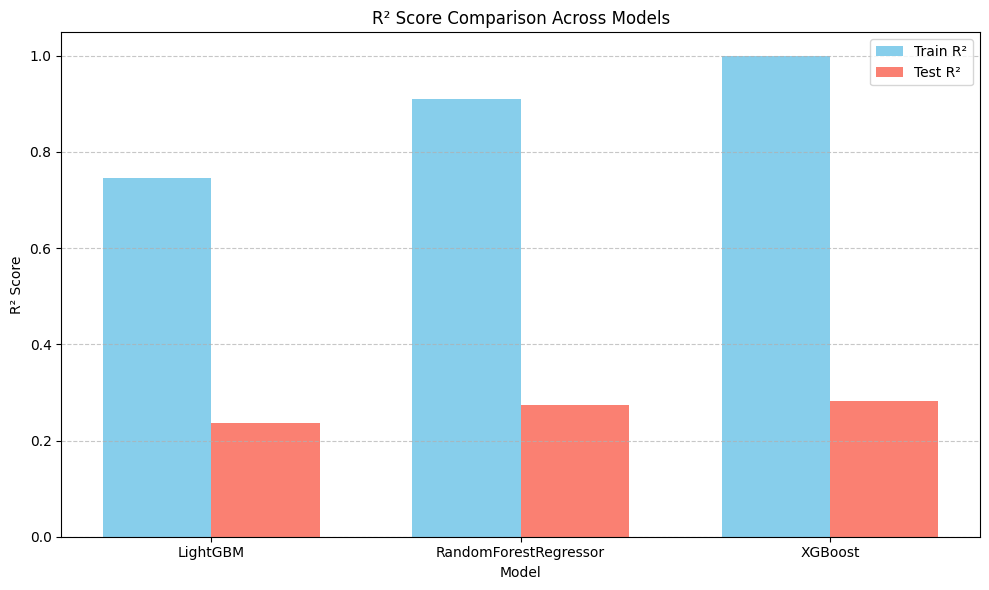

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# R2 Scores
train_scores = [0.746152574737631, 0.9109686987776875, 0.9987218778835609]
test_scores = [0.2371202660736179, 0.27334265657924384, 0.28208168294156966]
model_names = ['LightGBM', 'RandomForestRegressor', 'XGBoost']

# Bar width and positions
bar_width = 0.35
index = np.arange(len(model_names))

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(index, train_scores, bar_width, label='Train R²', color='skyblue')
plt.bar(index + bar_width, test_scores, bar_width, label='Test R²', color='salmon')

# Labeling
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('R² Score Comparison Across Models')
plt.xticks(index + bar_width / 2, model_names)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Cleaning data for test dataset

In [32]:
test_df = test_df.loc[:,test_df.nunique()>1]
test_df.drop(columns = ['trafficSource.adContent','trafficSource.adwordsClickInfo.slot','trafficSource.adwordsClickInfo.adNetworkType','trafficSource.keyword','trafficSource.adwordsClickInfo.page'], inplace = True)

#median for pageviews
test_df1 = test_df.copy()
median_pageviews = test_df1['pageViews'].median()

test_df1['pageViews'] = test_df1['pageViews'].fillna(median_pageviews)

print(f"Missing values in 'pageViews' imputed with the median ({median_pageviews}).")

# Impute missing values in'trafficSource.referralPath' with 'unknown'
test_df1['trafficSource.referralPath'] = test_df1['trafficSource.referralPath'].fillna('unknown')

print("Missing values in'trafficSource.referralPath' imputed with 'unknown'.")

Missing values in 'pageViews' imputed with the median (2.0).
Missing values in'trafficSource.referralPath' imputed with 'unknown'.


In [33]:
test_df1.isnull().sum()

userChannel                   0
date                          0
browser                       0
deviceType                    0
device.isMobile               0
os                            0
geoNetwork.city               0
geoNetwork.continent          0
locationCountry               0
geoNetwork.metro              0
geoNetwork.networkDomain      0
geoNetwork.region             0
geoNetwork.subContinent       0
totalHits                     0
pageViews                     0
trafficSource.campaign        0
trafficSource.medium          0
trafficSource.referralPath    0
trafficSource                 0
sessionId                     0
sessionNumber                 0
sessionStart                  0
userId                        0
geoCluster                    0
gclIdPresent                  0
dtype: int64

In [34]:
test_df1.shape

(29006, 25)

# Feature Engineering 

In [35]:
test_df1['date'] = pd.to_datetime(test_df1['date'], format='%Y%m%d')

test_df1['year'] = test_df1['date'].dt.year
test_df1['month'] = test_df1['date'].dt.month
test_df1['day'] = test_df1['date'].dt.day
test_df1['dayofweek'] = test_df1['date'].dt.dayofweek


In [36]:
test_df1['hits_pageviews'] = test_df1['totalHits'] * test_df1['pageViews']
test_df1['session_pageviews'] = test_df1['sessionNumber'] * test_df1['pageViews']


In [37]:
y_test_pred = best_model.predict(test_df1)
#y_test_pred = model.predict(test_df1)
test_df1['predicted_purchaseValue'] = y_test_pred

In [38]:
submission = pd.DataFrame({"id": range(len(test_df1)),"purchaseValue": test_df1['predicted_purchaseValue']})
submission.to_csv("submission.csv", index=False)
